<a href="https://colab.research.google.com/github/rohitrathod-4004/Patent-analysis/blob/main/Patent_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install -q transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 669.6 kB/s eta 0:00:00


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [4]:
from datasets import load_dataset

dataset = load_dataset(
    "ufukhaman/uspto_balanced_200k_ipc_classification"
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'ipc_class', 'subclass'],
        num_rows: 180342
    })
    test: Dataset({
        features: ['text', 'label', 'ipc_class', 'subclass'],
        num_rows: 20038
    })
})


In [3]:
print(dataset["train"][0])

{'text': 'DETAILED DESCRIPTION OF THE PREFERRED EMBODIMENTS \n\n Further scope of applicability of the present invention will become apparent from the detailed description given hereinafter. However, it should be understood that the detailed description and specific examples, while indicating preferred embodiments of the invention, are given by way of illustration only, since various changes and modifications within the spirit and scope of the invention will become apparent to those skilled in the art from this detailed description. \n\n FIG. 1 shows an inventive floor element essentially in a transportation state. When in use, the element 1 has a generally flat, rectangular shape and is comprised of a thin aluminium foil 10 of corresponding size and a thickness that is less than 200 m, preferably a thickness of 100 m. \n\n The foil 10 is carried by a floor sheet 11 , e.g. a cellular sheet, particle board, plaster board, or a technical equivalent. The sheet 11 includes through-extendin

In [4]:
print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']), 'ipc_class': Value('string'), 'subclass': Value('string')}


In [5]:
from collections import Counter

labels = dataset["train"]["label"]

print("Number of unique labels:", len(set(labels)))
print("Label distribution:", Counter(labels))

Number of unique labels: 8
Label distribution: Counter({2: 22581, 4: 22581, 0: 22564, 7: 22552, 1: 22530, 3: 22518, 6: 22518, 5: 22498})


In [6]:
print("IPC classes:", sorted(set(dataset["train"]["ipc_class"])))
print("Number of subclasses:", len(set(dataset["train"]["subclass"])))

IPC classes: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '5', '51', '54', '55', '56', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '71', '73', '79', '8', '81', '82', '87', '9', '92', '95', '98', 'O1']
Number of subclasses: 28


In [9]:
from collections import Counter

print("Unique labels:", len(set(dataset["train"]["label"])))
print("Labels:", sorted(set(dataset["train"]["label"])))

print("\nIPC classes:")
print(sorted(set(dataset["train"]["ipc_class"])))

subclasses = set(dataset["train"]["subclass"])

print("Number of unique subclasses:", len(subclasses))
print("Subclasses:", sorted(x for x in subclasses if x is not None))
print("Missing subclass values:", sum(x is None for x in dataset["train"]["subclass"]))

Unique labels: 8
Labels: [0, 1, 2, 3, 4, 5, 6, 7]

IPC classes:
['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '5', '51', '54', '55', '56', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '71', '73', '79', '8', '81', '82', '87', '9', '92', '95', '98', 'O1']
Number of unique subclasses: 28
Subclasses: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'd']
Missing subclass values: 1


In [13]:
!pip install -q sentencepiece

In [2]:
from transformers import BertTokenizer

MODEL_NAME = "anferico/bert-for-patents"

tokenizer = BertTokenizer.from_pretrained(
    MODEL_NAME,
    do_lower_case=True
)

print(tokenizer)
print("Vocabulary size:", tokenizer.vocab_size)
print("Max length:", tokenizer.model_max_length)

vocab.txt:   0%|          | 0.00/329k [00:00<?, ?B/s]

BertTokenizer(name_or_path='anferico/bert-for-patents', vocab_size=39859, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})
Vocabulary size: 39859
Max length: 1000000000000000019884624838656


In [5]:
sample_text = dataset["train"][0]["text"]

tokens = tokenizer(
    sample_text,
    truncation=True,
    max_length=256,
    padding="max_length",
    return_tensors="pt"
)

print("Input shape:", tokens["input_ids"].shape)
print(tokenizer.convert_ids_to_tokens(tokens["input_ids"][0][:50]))

Input shape: torch.Size([1, 256])
['[CLS]', 'detailed', 'description', 'of', 'the', 'preferred', 'embodiment', '##s', 'further', 'scope', 'of', 'applicability', 'of', 'the', 'present', 'invention', 'will', 'become', 'apparent', 'from', 'the', 'detailed', 'description', 'given', 'hereinafter', '.', 'however', ',', 'it', 'should', 'be', 'understood', 'that', 'the', 'detailed', 'description', 'and', 'specific', 'examples', ',', 'while', 'indicating', 'preferred', 'embodiment', '##s', 'of', 'the', 'invention', ',', 'are']


In [7]:
from transformers import BertConfig, BertModel

MODEL_NAME = "anferico/bert-for-patents"

config = BertConfig.from_pretrained(MODEL_NAME)

print(config)

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 1024,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 16,
  "num_hidden_layers": 24,
  "pad_token_id": 0,
  "tie_word_embeddings": true,
  "transformers_version": "5.16.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 39859
}



In [8]:
model = BertModel.from_pretrained(
    MODEL_NAME,
    config=config
)

print("Model loaded successfully!")

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.38GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: anferico/bert-for-patents
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [10]:
sample_text = dataset["train"][0]["text"]

inputs = tokenizer(
    sample_text,
    truncation=True,
    max_length=256,
    padding="max_length",
    return_tensors="pt"
)

inputs = {k: v.to(device) for k, v in inputs.items()}

In [11]:
with torch.no_grad():
    outputs = model(**inputs)

print(outputs.last_hidden_state.shape)

torch.Size([1, 256, 1024])


In [12]:
import torch.nn as nn

classifier = nn.Linear(1024, 8)

In [13]:
import torch
import torch.nn as nn

class PatentClassifier(nn.Module):
    def __init__(self, bert_model, num_classes=8):
        super().__init__()

        self.bert = bert_model
        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = outputs.last_hidden_state[:, 0, :]

        logits = self.classifier(cls_embedding)

        return logits

In [14]:
model = PatentClassifier(model, num_classes=8)
model = model.to(device)

In [15]:
sample = dataset["train"][0]

inputs = tokenizer(
    sample["text"],
    truncation=True,
    max_length=256,
    padding="max_length",
    return_tensors="pt"
)

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    logits = model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )

print("Logits shape:", logits.shape)
print("Logits:", logits)

Logits shape: torch.Size([1, 8])
Logits: tensor([[-0.4299, -0.1205, -0.7053,  0.4556,  0.3887, -0.6428, -0.3140, -0.5462]],
       device='cuda:0')


In [16]:
predicted_class = torch.argmax(logits, dim=1)

print("Predicted label:", predicted_class.item())
print("Actual label:", sample["label"])

Predicted label: 3
Actual label: 5


In [17]:
from sklearn.model_selection import train_test_split

# Get labels
labels = dataset["train"]["label"]

train_indices, val_indices = train_test_split(
    range(len(labels)),
    test_size=0.10,
    random_state=42,
    stratify=labels
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

Training samples: 162307
Validation samples: 18035


In [18]:
import random

random.seed(42)

train_indices_small = random.sample(train_indices, 30000)
val_indices_small = random.sample(val_indices, 5000)

print("Train:", len(train_indices_small))
print("Validation:", len(val_indices_small))

Train: 30000
Validation: 5000


In [19]:
train_data = dataset["train"].select(train_indices_small)
val_data = dataset["train"].select(val_indices_small)

print(train_data)
print(val_data)

Dataset({
    features: ['text', 'label', 'ipc_class', 'subclass'],
    num_rows: 30000
})
Dataset({
    features: ['text', 'label', 'ipc_class', 'subclass'],
    num_rows: 5000
})


In [20]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256,
        padding="max_length"
    )

In [21]:
tokenized_train = train_data.map(
    tokenize_function,
    batched=True,
    remove_columns=["text", "ipc_class", "subclass"]
)

tokenized_val = val_data.map(
    tokenize_function,
    batched=True,
    remove_columns=["text", "ipc_class", "subclass"]
)

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [22]:
print(tokenized_train)
print(tokenized_train[0])

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 30000
})
{'label': 6, 'input_ids': [2, 6516, 6077, 1735, 1662, 1661, 9983, 6146, 1670, 4011, 1042, 7765, 30684, 1758, 1016, 8454, 3411, 1015, 1701, 3806, 1789, 1669, 1042, 1758, 1016, 8454, 7950, 1016, 31152, 3411, 1015, 1689, 1789, 1017, 1674, 1668, 1789, 1673, 1708, 1684, 8805, 1662, 14737, 1668, 1774, 1665, 2858, 1684, 8805, 1662, 6900, 4865, 1695, 30100, 4015, 2044, 1661, 15583, 4611, 1662, 1661, 9679, 1015, 1042, 7149, 3411, 1668, 2221, 1017, 1674, 1668, 1701, 1789, 1673, 1730, 1661, 8805, 1662, 14737, 1696, 1042, 2032, 6175, 1015, 1695, 9042, 2756, 1015, 1749, 1661, 8805, 1662, 6900, 4865, 1015, 1735, 2679, 1662, 30591, 1762, 4923, 1015, 1663, 1661, 7149, 3411, 3209, 1665, 1661, 13637, 1665, 1687, 1664, 1042, 2032, 4611, 1749, 1714, 4690, 2960, 1017, 1688, 9240, 1703, 1707, 11726, 36392, 30591, 1017, 1042, 6259, 1662, 1661, 3602, 6623, 1729, 1687, 1844, 1664, 1528, 1661, 36392, 37011

In [23]:
columns = ["input_ids", "attention_mask", "token_type_ids", "label"]

tokenized_train.set_format(
    type="torch",
    columns=columns
)

tokenized_val.set_format(
    type="torch",
    columns=columns
)

In [24]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(
    tokenized_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    tokenized_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 7500
Validation batches: 1250


In [25]:
import torch
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

In [26]:
batch = next(iter(train_loader))

print("Input IDs:", batch["input_ids"].shape)
print("Attention mask:", batch["attention_mask"].shape)
print("Labels:", batch["label"].shape)

Input IDs: torch.Size([4, 256])
Attention mask: torch.Size([4, 256])
Labels: torch.Size([4])


In [27]:
batch = {
    k: v.to(device)
    for k, v in batch.items()
}

In [28]:
model.train()

optimizer.zero_grad()

logits = model(
    input_ids=batch["input_ids"],
    attention_mask=batch["attention_mask"]
)

print("Logits shape:", logits.shape)

Logits shape: torch.Size([4, 8])


In [29]:
loss = criterion(
    logits,
    batch["label"]
)

print("Loss:", loss.item())

Loss: 2.11875581741333


In [30]:
loss.backward()

In [31]:
optimizer.step()

In [32]:
print(
    f"GPU memory allocated: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

print(
    f"GPU memory reserved: "
    f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

print(
    f"Peak GPU memory: "
    f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GB"
)

GPU memory allocated: 5.14 GB
GPU memory reserved: 6.48 GB
Peak GPU memory: 6.42 GB


In [33]:
# Reload original PatentBERT
bert_model = BertModel.from_pretrained(
    MODEL_NAME,
    config=config
)

# Create a fresh classification model
model = PatentClassifier(bert_model, num_classes=8)

# Move to GPU
model = model.to(device)

print("Fresh model ready!")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: anferico/bert-for-patents
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fresh model ready!


In [34]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

In [37]:
#confirm the clean model
print("Model device:", next(model.parameters()).device)

print(
    "Classifier weight shape:",
    model.classifier.weight.shape
)

Model device: cuda:0
Classifier weight shape: torch.Size([8, 1024])


In [38]:
BATCH_SIZE = 4

train_loader = DataLoader(
    tokenized_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    tokenized_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [41]:
import torch
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

GRADIENT_ACCUMULATION = 4
EPOCHS = 1

In [42]:
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

model.train()
optimizer.zero_grad()

total_loss = 0

for step, batch in enumerate(train_loader):

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["label"].to(device)

    # Mixed precision
    with autocast("cuda", dtype=torch.float16):

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(logits, labels)

        # Important for gradient accumulation
        loss = loss / GRADIENT_ACCUMULATION

    scaler.scale(loss).backward()

    total_loss += loss.item()

    # Update weights every 4 batches
    if (step + 1) % GRADIENT_ACCUMULATION == 0:

        scaler.step(optimizer)
        scaler.update()

        optimizer.zero_grad()

    # Progress
    if (step + 1) % 100 == 0:

        print(
            f"Step {step + 1}/{len(train_loader)} | "
            f"Loss: {loss.item():.4f}"
        )

Step 100/7500 | Loss: 0.2982
Step 200/7500 | Loss: 0.2304
Step 300/7500 | Loss: 0.2022
Step 400/7500 | Loss: 0.0438
Step 500/7500 | Loss: 0.4761
Step 600/7500 | Loss: 0.0632
Step 700/7500 | Loss: 0.1730
Step 800/7500 | Loss: 0.4242
Step 900/7500 | Loss: 0.5666
Step 1000/7500 | Loss: 0.3571
Step 1100/7500 | Loss: 0.0728
Step 1200/7500 | Loss: 0.1438
Step 1300/7500 | Loss: 0.1494
Step 1400/7500 | Loss: 0.2811
Step 1500/7500 | Loss: 0.1579
Step 1600/7500 | Loss: 0.0606
Step 1700/7500 | Loss: 0.0874
Step 1800/7500 | Loss: 0.3357
Step 1900/7500 | Loss: 0.1665
Step 2000/7500 | Loss: 0.6521
Step 2100/7500 | Loss: 0.4972
Step 2200/7500 | Loss: 0.3736
Step 2300/7500 | Loss: 0.1580
Step 2400/7500 | Loss: 0.1319
Step 2500/7500 | Loss: 0.1251
Step 2600/7500 | Loss: 0.2611
Step 2700/7500 | Loss: 0.0561
Step 2800/7500 | Loss: 0.3821
Step 2900/7500 | Loss: 0.0569
Step 3000/7500 | Loss: 0.0576
Step 3100/7500 | Loss: 0.2915
Step 3200/7500 | Loss: 0.5733
Step 3300/7500 | Loss: 0.0587
Step 3400/7500 | Lo

In [43]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

model.eval()

val_preds = []
val_labels = []

total_val_loss = 0.0

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        with autocast("cuda", dtype=torch.float16):

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

        total_val_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())


val_accuracy = accuracy_score(
    val_labels,
    val_preds
)

val_f1 = f1_score(
    val_labels,
    val_preds,
    average="macro"
)

print("Validation Loss:", total_val_loss / len(val_loader))
print("Validation Accuracy:", val_accuracy)
print("Validation Macro F1:", val_f1)

print("\nClassification Report:")
print(
    classification_report(
        val_labels,
        val_preds,
        target_names=["A","B","C","D","E","F","G","H"]
    )
)

Validation Loss: 0.7476980850219727
Validation Accuracy: 0.7566
Validation Macro F1: 0.7529949552025106

Classification Report:
              precision    recall  f1-score   support

           A       0.68      0.80      0.74       612
           B       0.70      0.54      0.61       626
           C       0.74      0.83      0.78       612
           D       0.89      0.84      0.86       604
           E       0.81      0.88      0.85       675
           F       0.75      0.75      0.75       620
           G       0.75      0.63      0.68       609
           H       0.74      0.78      0.76       642

    accuracy                           0.76      5000
   macro avg       0.76      0.76      0.75      5000
weighted avg       0.76      0.76      0.75      5000



In [44]:
# Fresh PatentBERT
bert_model = BertModel.from_pretrained(
    MODEL_NAME,
    config=config
)

model = PatentClassifier(
    bert_model,
    num_classes=8
).to(device)

print("Fresh model created.")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: anferico/bert-for-patents
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fresh model created.


In [45]:
from transformers import get_linear_schedule_with_warmup

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

EPOCHS = 2

total_training_steps = (
    len(train_loader) * EPOCHS
) // GRADIENT_ACCUMULATION

warmup_steps = int(0.1 * total_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

print("Total training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)

Total training steps: 3750
Warmup steps: 375


In [46]:
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0.0
    optimizer.zero_grad()

    print(f"\n========== Epoch {epoch + 1}/{EPOCHS} ==========")

    for step, batch in enumerate(train_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        with autocast("cuda", dtype=torch.float16):

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

            loss = loss / GRADIENT_ACCUMULATION

        scaler.scale(loss).backward()

        total_loss += loss.item()

        if (step + 1) % GRADIENT_ACCUMULATION == 0:

            scaler.step(optimizer)
            scaler.update()

            optimizer.zero_grad()

            scheduler.step()

        if (step + 1) % 500 == 0:

            print(
                f"Epoch {epoch + 1} | "
                f"Step {step + 1}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f} | "
                f"LR: {scheduler.get_last_lr()[0]:.2e}"
            )

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1} completed | "
        f"Average Loss: {avg_loss:.4f}"
    )


========== Epoch 1/2 ==========
Epoch 1 | Step 500/7500 | Loss: 0.2543 | LR: 6.67e-06
Epoch 1 | Step 1000/7500 | Loss: 0.5131 | LR: 1.33e-05
Epoch 1 | Step 1500/7500 | Loss: 0.6148 | LR: 2.00e-05
Epoch 1 | Step 2000/7500 | Loss: 0.0466 | LR: 1.93e-05
Epoch 1 | Step 2500/7500 | Loss: 0.0899 | LR: 1.85e-05
Epoch 1 | Step 3000/7500 | Loss: 0.0529 | LR: 1.78e-05
Epoch 1 | Step 3500/7500 | Loss: 0.1932 | LR: 1.70e-05
Epoch 1 | Step 4000/7500 | Loss: 0.2147 | LR: 1.63e-05
Epoch 1 | Step 4500/7500 | Loss: 0.5430 | LR: 1.56e-05
Epoch 1 | Step 5000/7500 | Loss: 0.2802 | LR: 1.48e-05
Epoch 1 | Step 5500/7500 | Loss: 0.1247 | LR: 1.41e-05
Epoch 1 | Step 6000/7500 | Loss: 0.2595 | LR: 1.33e-05
Epoch 1 | Step 6500/7500 | Loss: 0.3791 | LR: 1.26e-05
Epoch 1 | Step 7000/7500 | Loss: 0.1415 | LR: 1.19e-05
Epoch 1 | Step 7500/7500 | Loss: 0.0364 | LR: 1.11e-05
Epoch 1 completed | Average Loss: 0.2063

========== Epoch 2/2 ==========
Epoch 2 | Step 500/7500 | Loss: 0.0667 | LR: 1.04e-05
Epoch 2 | Step 

In [47]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

model.eval()

val_preds = []
val_labels = []

total_val_loss = 0.0

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        with autocast("cuda", dtype=torch.float16):

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

        total_val_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())


val_accuracy = accuracy_score(
    val_labels,
    val_preds
)

val_f1 = f1_score(
    val_labels,
    val_preds,
    average="macro"
)

print("Validation Loss:", total_val_loss / len(val_loader))
print("Validation Accuracy:", val_accuracy)
print("Validation Macro F1:", val_f1)

print("\nClassification Report:")
print(
    classification_report(
        val_labels,
        val_preds,
        target_names=["A","B","C","D","E","F","G","H"]
    )
)

Validation Loss: 0.6809909795761109
Validation Accuracy: 0.7792
Validation Macro F1: 0.7779150910378131

Classification Report:
              precision    recall  f1-score   support

           A       0.79      0.76      0.78       612
           B       0.67      0.62      0.65       626
           C       0.77      0.80      0.78       612
           D       0.88      0.88      0.88       604
           E       0.85      0.88      0.87       675
           F       0.76      0.77      0.77       620
           G       0.72      0.75      0.73       609
           H       0.78      0.76      0.77       642

    accuracy                           0.78      5000
   macro avg       0.78      0.78      0.78      5000
weighted avg       0.78      0.78      0.78      5000



In [48]:
# Save current best model (Epoch 2)
best_f1 = 0.7779150910378131

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_f1": best_f1,
}, "patentbert_best_epoch2.pt")

print("Saved current best checkpoint.")

Saved current best checkpoint.


In [49]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-6,
    weight_decay=0.01
)

print("New learning rate:", optimizer.param_groups[0]["lr"])

New learning rate: 5e-06


In [50]:
model.train()

total_loss = 0.0

for step, batch in enumerate(train_loader, start=1):

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["label"].to(device)

    optimizer.zero_grad()

    with autocast("cuda", dtype=torch.float16):

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(logits, labels)

    loss.backward()

    optimizer.step()

    total_loss += loss.item()

    if step % 500 == 0:
        print(
            f"Epoch 3 | Step {step}/{len(train_loader)} "
            f"| Loss: {loss.item():.4f}"
        )

print(
    f"Epoch 3 completed | "
    f"Average Loss: {total_loss / len(train_loader):.4f}"
)

Epoch 3 | Step 500/7500 | Loss: 0.2245
Epoch 3 | Step 1000/7500 | Loss: 0.3274
Epoch 3 | Step 1500/7500 | Loss: 0.0259
Epoch 3 | Step 2000/7500 | Loss: 0.1739
Epoch 3 | Step 2500/7500 | Loss: 0.1137
Epoch 3 | Step 3000/7500 | Loss: 0.0932
Epoch 3 | Step 3500/7500 | Loss: 0.0909
Epoch 3 | Step 4000/7500 | Loss: 0.3213
Epoch 3 | Step 4500/7500 | Loss: 0.1689
Epoch 3 | Step 5000/7500 | Loss: 0.1162
Epoch 3 | Step 5500/7500 | Loss: 0.0845
Epoch 3 | Step 6000/7500 | Loss: 0.0234
Epoch 3 | Step 6500/7500 | Loss: 0.0142
Epoch 3 | Step 7000/7500 | Loss: 0.0623
Epoch 3 | Step 7500/7500 | Loss: 0.4526
Epoch 3 completed | Average Loss: 0.3286


In [51]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

model.eval()

val_preds = []
val_labels = []

total_val_loss = 0.0

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        with autocast("cuda", dtype=torch.float16):

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

        total_val_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

val_accuracy = accuracy_score(val_labels, val_preds)

val_f1 = f1_score(
    val_labels,
    val_preds,
    average="macro"
)

print("Validation Loss:", total_val_loss / len(val_loader))
print("Validation Accuracy:", val_accuracy)
print("Validation Macro F1:", val_f1)

print("\nClassification Report:")
print(
    classification_report(
        val_labels,
        val_preds,
        target_names=["A","B","C","D","E","F","G","H"]
    )
)

Validation Loss: 0.7661991785526275
Validation Accuracy: 0.765
Validation Macro F1: 0.7634376135800297

Classification Report:
              precision    recall  f1-score   support

           A       0.77      0.74      0.75       612
           B       0.64      0.61      0.63       626
           C       0.78      0.76      0.77       612
           D       0.87      0.88      0.87       604
           E       0.83      0.87      0.85       675
           F       0.76      0.75      0.75       620
           G       0.74      0.69      0.71       609
           H       0.74      0.81      0.77       642

    accuracy                           0.77      5000
   macro avg       0.76      0.76      0.76      5000
weighted avg       0.76      0.77      0.76      5000



In [53]:
# Load the best checkpoint (Epoch 2)

checkpoint = torch.load(
    "patentbert_best_epoch2.pt",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

best_f1 = checkpoint["best_f1"]

print("Best checkpoint loaded!")
print("Best Macro F1:", best_f1)

model.to(device)
model.eval()

Best checkpoint loaded!
Best Macro F1: 0.7779150910378131


PatentClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(39859, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,), eps=1e-12,

Confusion Matrix:
[[467  35  44  10  10  16  25   5]
 [ 37 389  41  21  36  62  23  17]
 [ 22  27 491  26   7   6  10  23]
 [ 11  22  22 532   5   6   5   1]
 [ 11  24   5   0 596  25  10   4]
 [ 20  37  11   9  35 478  10  20]
 [ 18  27  14   3   7  21 454  65]
 [  4  19  11   2   6  14  97 489]]


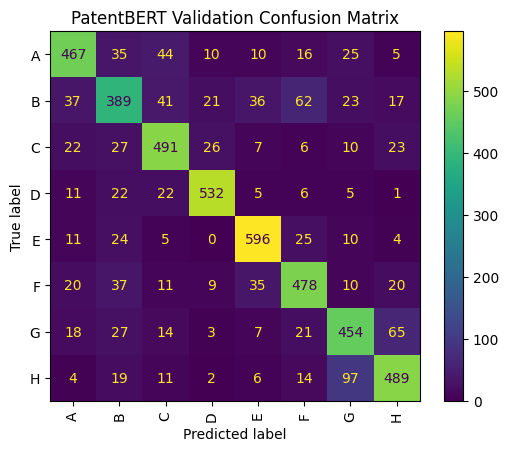

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()

val_preds = []
val_labels = []

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        with autocast("cuda", dtype=torch.float16):

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        preds = torch.argmax(logits, dim=1)

        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(val_labels, val_preds)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["A","B","C","D","E","F","G","H"]
)

disp.plot(
    xticks_rotation="vertical"
)

plt.title("PatentBERT Validation Confusion Matrix")
plt.show()

**Now for complete dataset**

In [55]:
print(dataset)

print("\nTrain size:", len(dataset["train"]))
print("Test size:", len(dataset["test"]))

print("\nTrain features:")
print(dataset["train"].features)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'ipc_class', 'subclass'],
        num_rows: 180342
    })
    test: Dataset({
        features: ['text', 'label', 'ipc_class', 'subclass'],
        num_rows: 20038
    })
})

Train size: 180342
Test size: 20038

Train features:
{'text': Value('string'), 'label': ClassLabel(names=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']), 'ipc_class': Value('string'), 'subclass': Value('string')}


In [56]:
from collections import Counter

# Create stratified train/validation split
split_dataset = dataset["train"].train_test_split(
    test_size=0.05,
    stratify_by_column="label",
    seed=42
)

train_full = split_dataset["train"]
val_full = split_dataset["test"]

print("Full training set:", len(train_full))
print("Validation set:", len(val_full))

print("\nTraining label distribution:")
print(Counter(train_full["label"]))

print("\nValidation label distribution:")
print(Counter(val_full["label"]))

Full training set: 171324
Validation set: 9018

Training label distribution:
Counter({4: 21452, 2: 21452, 0: 21436, 7: 21424, 1: 21403, 6: 21392, 3: 21392, 5: 21373})

Validation label distribution:
Counter({4: 1129, 2: 1129, 0: 1128, 7: 1128, 1: 1127, 3: 1126, 6: 1126, 5: 1125})


In [57]:
import os

print(os.path.exists("patentbert_best_epoch2.pt"))

True


In [60]:
import shutil
from google.colab import drive

drive.mount('/content/drive')

shutil.copy(
    "patentbert_best_epoch2.pt",
    "/content/drive/MyDrive/patentbert_best_epoch2.pt"
)

print("Checkpoint saved to Google Drive!")

MessageError: Error: credential propagation was unsuccessful